---
---

<h1 style="color:gold"><b>Scaling Technique </b></h1>

---
---


<h3 style="color:lightblue"><b>Defination- </b>it is a pre-processing technique which scales feature columns equally</h3>

```
* Standardzition- not at fixed range
        1.Standard Scale- less outlayers (uses mean)
        2.Robust Scale- more outlayers (uses median)
* Normalization- fixed range (0, 1)
        1.MinMax Scale- less outlayres (uses Min Max)
```

<h3 style="color:skyblue"><b>when to use- </b>numeric columns are in different range</h3>


<h3 style="color:skyblue"><b> When not to use scaling</b></h3>

```
PCA
Decision Tree
Random Forest
xgboosts
```


| Algorithm | Scaling Needed| Preferred Scaler |
|---|---|---|
|Linear Regression |	Yes|	StandardScaler|
|Logistic Regression|	Yes|	StandardScaler|
|KNN	|Yes|	MinMaxScaler|
|K-Means	|Yes	|MinMaxScaler|
|SVM	|Yes	|StandardScaler/MinMaxScaler|
|Neural Networks	|Yes	|MinMaxScaler|
|PCA    |yes| standardScaler|
|Decision Tree    |no| None|
|Random Forest    |no| None|
|xgboost    |no| None|



---

<h3 style="color:skyblue">import and read dataset</h3>


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import recall_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler,robust_scale,minmax_scale

In [14]:
df = pd.read_csv("../../../../Data/job_salary_prediction_dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [15]:
df.corr(numeric_only=True)

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000


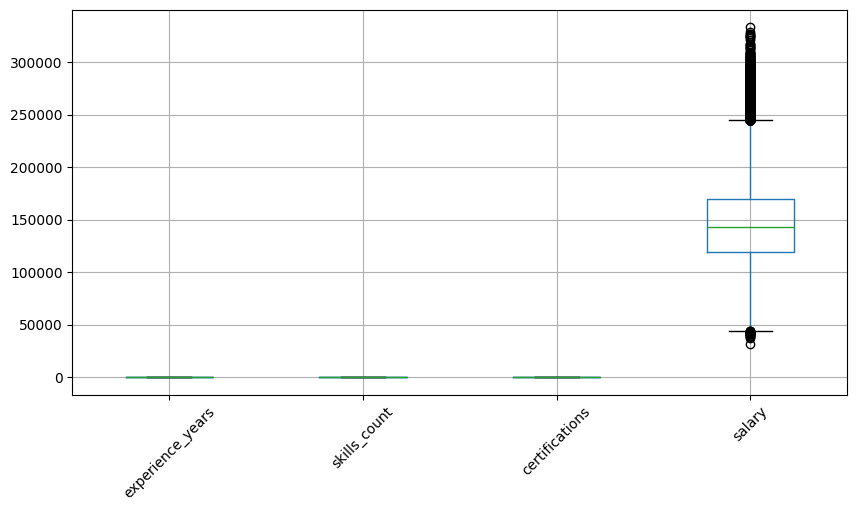

In [16]:
df.boxplot(figsize=(10,5))
plt.xticks(rotation=45)
plt.show()

In [17]:
df.describe().round()

,experience_years,skills_count,certifications,salary
count,250000.0,250000.0,250000.0,250000.0
mean,10.0,10.0,2.0,145718.0
std,6.0,5.0,2.0,37408.0
min,0.0,1.0,0.0,31867.0
25%,5.0,5.0,1.0,119358.0
50%,10.0,10.0,2.0,143453.0
75%,15.0,15.0,4.0,169492.0
max,20.0,19.0,5.0,333046.0



<h1 style="color:yellow"><b>Conclusion</b></h1>

```

there are zero outlayres in Experience_Year, skills_count, certification

so we will use standard scale

```

In [18]:
scale = StandardScaler()

In [19]:
x = df[["experience_years", "skills_count", "certifications"]]
x

,experience_years,skills_count,certifications
0,10,2,2
1,5,17,0
2,18,4,1
3,19,13,0
4,15,7,0
...,...,...,...
249995,17,2,1
249996,20,7,2
249997,1,12,0
249998,0,2,5


In [20]:
updated_x = scale.fit_transform(x)
updated_x

array([[-8.92322321e-04, -1.45964725e+00, -2.88271936e-01],
       [-8.25894468e-01,  1.27794008e+00, -1.46028059e+00],
       [ 1.31911111e+00, -1.09463561e+00, -8.74276261e-01],
       ...,
       [-1.48589618e+00,  3.65410967e-01, -1.46028059e+00],
       [-1.65089661e+00, -1.45964725e+00,  1.46974104e+00],
       [ 9.89110253e-01, -1.45964725e+00,  1.46974104e+00]],
      shape=(250000, 3))

In [21]:
scale = robust_scale(x)

In [22]:
scale

array([[ 0.        , -0.8       ,  0.        ],
       [-0.5       ,  0.7       , -0.66666667],
       [ 0.8       , -0.6       , -0.33333333],
       ...,
       [-0.9       ,  0.2       , -0.66666667],
       [-1.        , -0.8       ,  1.        ],
       [ 0.6       , -0.8       ,  1.        ]], shape=(250000, 3))

In [23]:
df = pd.read_csv("../Notes/Scaling/standardscaler.csv")
df

,Feature1,Feature2,Feature3,Target
0,7,506815,78179.054805,147107.322662
1,4,293822,70538.588873,127684.231772
2,8,77218,44636.920014,87982.249559
3,5,588518,86421.631346,166046.587018
4,7,771044,55814.069145,101011.603738
...,...,...,...,...
995,8,318348,38587.511702,68752.511537
996,1,183958,79172.046754,144130.196824
997,9,990156,59598.924619,103252.136934
998,7,278707,10126.081336,22002.231220


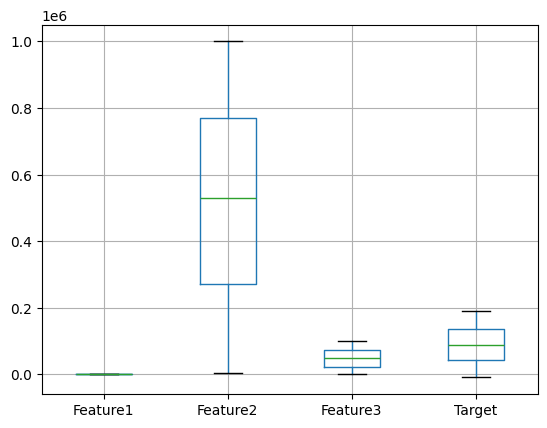

In [24]:
df.boxplot()
plt.show()

# less out layers so we will use standard scaler

In [25]:
scale = StandardScaler()

In [26]:
scale.fit_transform(df[["Feature1", "Feature2"]])

array([[ 0.80764976, -0.05144565],
       [-0.34503781, -0.78560334],
       [ 1.19187895, -1.53220766],
       ...,
       [ 1.57610814,  1.61456458],
       [ 0.80764976, -0.83770268],
       [-0.729267  , -1.47669249]], shape=(1000, 2))

In [27]:
scale.transform(df["Feature3"])

c:\Users\MAYURESHWAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.